In [4]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    desc_add="clean",
)




EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


  Skipping 16 run 1 (no EOG data)
  Skipping 16 run 2 (no EOG data)
  Skipping 16 run 3 (no EOG data)
  Skipping 16 run 4 (no EOG data)
  Skipping 16 run 5 (no EOG data)

Per-run correlations (162 runs):


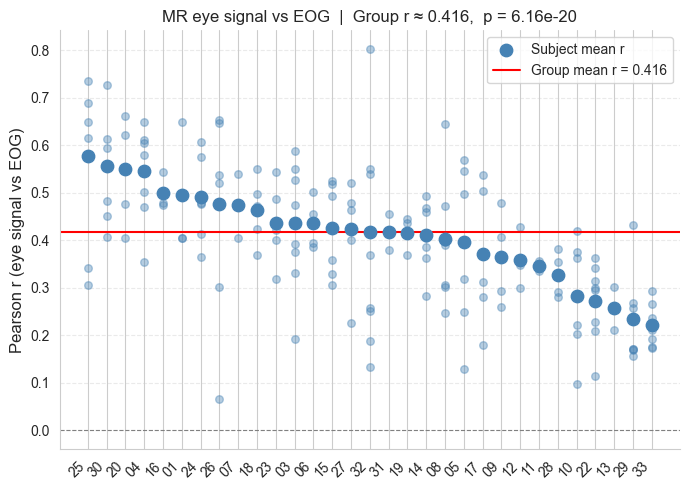

In [13]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ── 1. Collect per-run correlations ──────────────────────────────────────────

records = []

for subject, run, run_df in mrio.iter_run_events():
    eye_signal = run_df["mreyemove"]

    eog_rows = run_df["eog"]
    if eog_rows.isna().any():
        print(f"  Skipping {subject} run {run} (no EOG data)")
        continue

    eog_signal = eog_rows.values.astype(float)

    if len(eye_signal) != len(eog_signal):
        print(f"  Skipping {subject} run {run} (length mismatch: eye={len(eye_signal)}, eog={len(eog_signal)})")
        continue

    r, _ = stats.pearsonr(eye_signal, eog_signal)  
    if np.isnan(r):
        continue

    records.append(dict(
        subject=subject,
        run=run,
        r=r,
        n=len(eye_signal),
        mean_eye=np.mean(np.abs(eye_signal)),
        mean_eog=np.mean(np.abs(eog_signal)),
    ))

run_df = pd.DataFrame(records)
print(f"\nPer-run correlations ({len(run_df)} runs):")

# ── 2. Per-subject average r (Fisher z then back) ────────────────────────────

def fisher_mean_z(r_values):
    """Return Fisher-averaged correlation in z-space."""
    return np.mean(np.arctanh(np.clip(r_values, -0.9999, 0.9999)))

subj_df = (
    run_df.groupby("subject")["r"]
    .agg(z=lambda _r: fisher_mean_z(_r.values), n_runs="count")
    .reset_index()
)
subj_df["r"] = np.tanh(subj_df["z"])  # for display only


# Group-level

z_vals = subj_df["z"].values
mean_z = z_vals.mean()

group_r = np.tanh(mean_z)

t_stat, p_val = stats.ttest_1samp(subj_df["z"].values, 0)


# ── 4. Plot: per-subject mean r with individual runs ─────────────────────────

subj_plot = subj_df.sort_values("r", ascending=False).reset_index(drop=True)
p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

fig, ax = plt.subplots(figsize=(7, 5))

for i, row in subj_plot.iterrows():
    runs = run_df[run_df["subject"] == row["subject"]]["r"].values
    ax.scatter([i] * len(runs), runs, color="steelblue", alpha=0.4, s=30, zorder=2)

ax.scatter(range(len(subj_plot)), subj_plot["r"],
           color="steelblue", s=80, zorder=3, label="Subject mean r")

ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(group_r, color="red", lw=1.5, ls="-", label=f"Group mean r = {group_r:.3f}")

ax.set_xticks(range(len(subj_plot)))
ax.set_xticklabels(subj_plot["subject"].str.replace("sub-", ""), rotation=45, ha="right")
ax.set_ylabel("Pearson r (eye signal vs EOG)", fontsize=12)
ax.set_title(f"MR eye signal vs EOG  |  Group r ≈ {group_r:.3f},  p = {p_str}", fontsize=12)
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/Users/zach/2025_RA/matthias/final images/correlations/mreyemove_eog_r_per_subject.svg", dpi=300)
plt.show()

In [ ]:

# --- Run searchlight and plot ---
radius_mm = 38  # geodesic radius in mm
surf_mesh = "fsaverage7"

neighborhoods = build_fsaverage_neighborhoods(surf_mesh=surf_mesh, radius_mm=radius_mm)
corr_maps = {}
window_size = 3 


In [5]:
from SleepMReye.plotting import plot_surface_searchlight
from pathlib import Path
from nilearn.image import new_img_like
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation
from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
import nibabel as nib

threshold = 0.3
brain_mask = nib.load(mrio.second_level_glm_mask_path()).get_fdata().astype(bool)

for state_1 in ("W","S"):
    output_dir = Path("/Users/zach/2025_RA/matthias/final images/group_level/eog_mreyemove_rho_maps/thresholded")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{state_1}_correlation_map"
    data_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_1}", desc_add="clean-with-fd-clamped-original-sleep-incl-nrem3-flame")
    data_b,_ = mrio.load_FLAME_result(contrast=f"eog_{state_1}", desc_add="clean-with-fd-clamped-flame")    
    
    print(data_a.t_stat.shape)

    corr_maps, _ = run_fsaverage_surface_searchlight_correlation(
        data_b.t_stat, data_a.t_stat,
        surf_mesh=surf_mesh,
        neighborhoods=neighborhoods
    )

    # for hemi in ("left", "right"):
    #     c = corr_maps[hemi]
    #     mask = np.abs(c) > 1e-6
    #     print(f"  {hemi}: mean r={c[mask].mean():.3f}, "
    #           f">0.3: {(c > 0.3).sum() / len(c)}, "
    #           f"<-0.3: {(c < -0.3).sum() / len(c)}")

    plot_surface_searchlight(
        corr_maps,
        surf_mesh=surf_mesh,
        inflate=True,
        title=f"Searchlight r: {state_1} mreyemove vs eog ({radius_mm}mm geodesic)",
        output_file=f"{output_path}.png"
        # threshold=0.3,
    )
    

(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 88.3%
r_valid <= -0.3: 0.3%
n valid vertices = 163826
r_valid >=  0.3: 88.3%
r_valid <= -0.3: 0.3%
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 93.4%
r_valid <= -0.3: 0.0%
n valid vertices = 163842
r_valid >=  0.3: 93.4%
r_valid <= -0.3: 0.0%
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 93.5%
r_valid <= -0.3: 0.2%
n valid vertices = 163838
r_valid >=  0.3: 93.5%
r_valid <= -0.3: 0.2%
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 91.6%
r_valid <= -0.3: 1.1%
n valid vertices = 163842
r_valid >=  0.3: 91.6%
r_valid <= -0.3: 1.1%
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
